# Day 03 – Neural Networks using MLPClassifier on the Digits Dataset

## Objective

The objective of this notebook is to train a Multi-Layer Perceptron (MLP) classifier on the scikit-learn Digits dataset and compare its performance with Logistic Regression. Different hidden layer configurations are tested to study their effect on training accuracy, testing accuracy, overfitting, and learning behavior. The notebook also visualizes the training loss curve and records key observations.

## Step 1: Import Required Libraries

In this step, we import all the libraries required for the experiment.

- **NumPy** is used for numerical operations and working with arrays.
- **Matplotlib** is used for plotting graphs and visualizing results.
- **load_digits** loads the built-in handwritten digits dataset.
- **train_test_split** divides the dataset into training and testing sets.
- **LogisticRegression** is used as a baseline machine learning model.
- **MLPClassifier** is used to build a neural network classifier.
- **accuracy_score** is used to evaluate the performance of the models.

In [1]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score

## Step 2: Load and Explore the Digits Dataset

The Digits dataset is loaded from scikit-learn. It contains 1,797 grayscale images of handwritten digits (0–9). Each image has a size of **8 × 8 pixels**, which is flattened into **64 numerical features** for machine learning.

The corresponding labels indicate the correct digit represented by each image. Before training a model, it is important to inspect the dataset structure and verify that the data has been loaded correctly.

In [2]:
# Load the Digits dataset

digits = load_digits()

# Features (pixel values)
X = digits.data

# Labels (correct digit)
y = digits.target

# Print dataset information
print("Feature shape:", X.shape)
print("Label shape:", y.shape)

print("\nFirst image label:", y[0])

print("\nFirst image (flattened):")
print(X[0])

Feature shape: (1797, 64)
Label shape: (1797,)

First image label: 0

First image (flattened):
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


## Step 3: Split the Dataset into Training and Testing Sets

Machine learning models should be evaluated on data they have never seen before. Therefore, the dataset is divided into two parts:

- **Training Set:** Used to train the model.
- **Testing Set:** Used to evaluate the model's performance on unseen data.

In this notebook, 80% of the data is used for training and 20% is reserved for testing.

In [3]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Print the shapes of the new datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (1437, 64)
Testing features: (360, 64)
Training labels: (1437,)
Testing labels: (360,)


## Step 4: Train a Logistic Regression Model

Before training the neural network, a Logistic Regression model is trained as a baseline classifier. This allows us to compare the performance of a simple machine learning algorithm with a neural network.

The model is trained using the training dataset and then evaluated on both the training and testing datasets. The training accuracy shows how well the model learned from the training data, while the testing accuracy measures how well it performs on unseen data.

In [5]:
# Train a Logistic Regression model

log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions
train_predictions = log_reg.predict(X_train)
test_predictions = log_reg.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Print results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy: 0.9750


In [6]:
print(log_reg)

LogisticRegression(max_iter=1000, random_state=42)


In [7]:
print(train_accuracy)
print(test_accuracy)

1.0
0.975


## Step 5: Train a Multi-Layer Perceptron (MLP)

In this step, I trained my first neural network using Scikit-learn's `MLPClassifier`.

The model contains:
- One hidden layer
- 32 neurons
- ReLU activation function (default)
- Adam optimizer (default)

After training, I evaluated both the training and testing accuracy.

In [8]:
from sklearn.neural_network import MLPClassifier

# Create the MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    max_iter=1000,
    random_state=42
)

# Train the model
mlp.fit(X_train, y_train)

# Predictions
train_pred = mlp.predict(X_train)
test_pred = mlp.predict(X_test)

# Accuracy
mlp_train_accuracy = accuracy_score(y_train, train_pred)
mlp_test_accuracy = accuracy_score(y_test, test_pred)

print("MLP Training Accuracy:", round(mlp_train_accuracy, 4))
print("MLP Testing Accuracy :", round(mlp_test_accuracy, 4))

MLP Training Accuracy: 1.0
MLP Testing Accuracy : 0.9778


## Compare Logistic Regression with MLP

A Logistic Regression model was trained on the Digits dataset to create a baseline for comparison.

### Results

- Training Accuracy: **100.00%**
- Testing Accuracy: **97.50%**

The MLP model achieved:

- Training Accuracy: **100.00%**
- Testing Accuracy: **97.78%**

### Observation

Both models learned the training data perfectly.

The MLP achieved a slightly higher testing accuracy than Logistic Regression, indicating a small improvement in generalization.

The difference between training and testing accuracy is small for both models, suggesting that neither model suffers from significant overfitting.

## Step 6: Experiment with Different Hidden Layer Sizes

In this step, I trained multiple MLP models using different hidden layer configurations to observe how the network architecture affects training and testing accuracy.

The following configurations were tested:

- 8 neurons
- 32 neurons
- 128 neurons
- Two hidden layers (64, 32)

Finally, the results were compared in a table.

In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Different hidden layer configurations
hidden_layers = [
    (8,),
    (32,),
    (128,),
    (64, 32)
]

results = []

for layer in hidden_layers:

    # Create model
    model = MLPClassifier(
        hidden_layer_sizes=layer,
        max_iter=1000,
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Store results
    results.append([layer, train_acc, test_acc])

# Create table
results_df = pd.DataFrame(
    results,
    columns=[
        "Hidden Layer",
        "Training Accuracy",
        "Testing Accuracy"
    ]
)

results_df

,Hidden Layer,Training Accuracy,Testing Accuracy
0,"(8,)",1.0,0.944444
1,"(32,)",1.0,0.977778
2,"(128,)",1.0,0.977778
3,"(64, 32)",1.0,0.966667


## Step 7: Observations

### Results Summary

| Hidden Layer | Training Accuracy | Testing Accuracy |
|--------------|------------------:|-----------------:|
| (8,) | 100.00% | 94.44% |
| (32,) | 100.00% | 97.78% |
| (128,) | 100.00% | 97.78% |
| (64, 32) | 100.00% | 96.67% |

### Observations

- All models achieved 100% training accuracy.
- Increasing the hidden layer size from 8 to 32 significantly improved testing accuracy.
- Increasing from 32 to 128 neurons did not improve testing accuracy further.
- The model with two hidden layers (64, 32) performed slightly worse than the single hidden layer with 32 neurons.
- This experiment shows that a larger neural network does not always produce better test accuracy.

## Step 7: Plot the Loss Curve

In this step, I plotted the training loss curve of the MLP model.

The loss curve shows how the error decreases during training. As the neural network learns through backpropagation and gradient descent, the loss should gradually decrease over iterations.

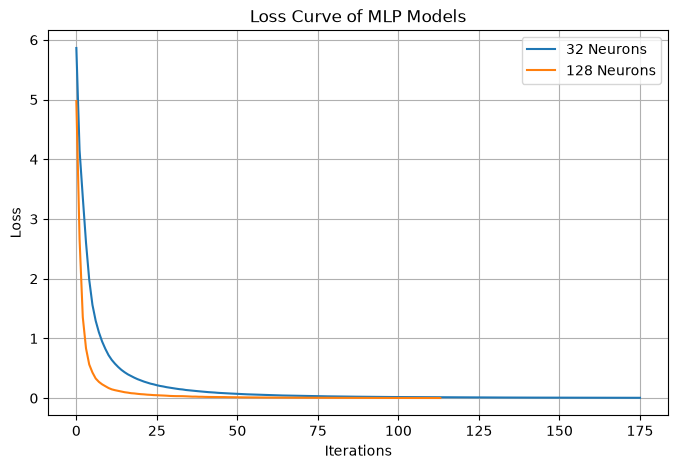

In [10]:
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

# Train MLP with 32 neurons
mlp32 = MLPClassifier(
    hidden_layer_sizes=(32,),
    max_iter=1000,
    random_state=42
)

mlp32.fit(X_train, y_train)

# Train MLP with 128 neurons
mlp128 = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=1000,
    random_state=42
)

mlp128.fit(X_train, y_train)

# Plot loss curves
plt.figure(figsize=(8,5))

plt.plot(mlp32.loss_curve_, label="32 Neurons")
plt.plot(mlp128.loss_curve_, label="128 Neurons")

plt.title("Loss Curve of MLP Models")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()

plt.grid(True)

plt.show()

# Observations

## Model Comparison

- Logistic Regression achieved a **training accuracy of 100%** and a **testing accuracy of 97.50%**.
- The MLP Classifier with one hidden layer of **32 neurons** achieved a **training accuracy of 100%** and a slightly higher **testing accuracy of 97.78%**.
- This shows that the MLP model performed slightly better than Logistic Regression on the digits dataset.

## Hidden Layer Experiments

Different hidden layer sizes produced the following results:

| Hidden Layer | Training Accuracy | Testing Accuracy |
|--------------|-------------------|------------------|
| 8            | 100%              | 94.44%           |
| 32           | 100%              | 97.78%           |
| 128          | 100%              | 97.78%           |
| (64, 32)     | 100%              | 96.67%           |

## Loss Curve

- The loss decreased rapidly during the initial training iterations and then gradually became stable.
- This indicates that the model was learning effectively.
- The model with **128 neurons** reduced the loss faster than the model with **32 neurons**, showing that a larger network